# **Ejercicio 4: Redes neuronales convolucionales**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

import config as cfg
import modelado as m

datos = m.cargar_tensores()

[ok] entrada (64, 64, 1)
[cargado]  tensores -> train 12180, val 2610, test 2610


## **Arquitecturas**

**CNN base.** Tres bloques de convolucion y pooling, luego una capa densa. La imagen pasa de
64x64 a 8x8 antes del `Flatten`. El tercer bloque esta por costo, no por profundidad: sin el,
el `Flatten` entregaria 16,384 caracteristicas y la red cargaria 2.1 millones de parametros en
una sola capa densa.

**CNN regularizada.** Los mismos tres bloques, mas BatchNorm despues de cada convolucion y
dropout despues de cada pooling y antes de la salida. Se espera que la base sobreajuste, dado
que los fondos y encuadres del dataset son muy uniformes, y que la regularizacion cierre la
brecha.

In [2]:
def construir_base(filtros=(32, 64, 64), densa=128):
    capas = [tf.keras.layers.Input(shape=cfg.FORMA_ENTRADA)]
    for f in filtros:
        capas += [
            tf.keras.layers.Conv2D(f, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(2),
        ]
    capas += [
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(densa, activation="relu"),
        tf.keras.layers.Dense(cfg.NUM_CLASES, activation="softmax"),
    ]
    return tf.keras.Sequential(capas, name="cnn_base")


def construir_regularizada(filtros=(32, 64, 64), densa=128, dropout_conv=0.25, dropout_densa=0.5):
    capas = [tf.keras.layers.Input(shape=cfg.FORMA_ENTRADA)]
    for f in filtros:
        capas += [
            tf.keras.layers.Conv2D(f, 3, padding="same", use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.Dropout(dropout_conv),
        ]
    capas += [
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(densa, activation="relu"),
        tf.keras.layers.Dropout(dropout_densa),
        tf.keras.layers.Dense(cfg.NUM_CLASES, activation="softmax"),
    ]
    return tf.keras.Sequential(capas, name="cnn_regularizada")

In [3]:
construir_base().summary()

Model: "cnn_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 583,901 (2.23 MB)

 Trainable params: 583,901 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
construir_regularizada().summary()

Model: "cnn_regularizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 584,381 (2.23 MB)

 Trainable params: 584,061 (2.23 MB)

 Non-trainable params: 320 (1.25 KB)

## **Utilidades de visualizacion**

Se definen una sola vez y se reutilizan para cada variante.

In [5]:
def graficar_curvas(historial, titulo):
    h = historial.history
    fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

    ejes[0].plot(h["accuracy"], label="entrenamiento")
    ejes[0].plot(h["val_accuracy"], label="validacion")
    ejes[0].set_title(f"{titulo}: accuracy")
    ejes[0].set_xlabel("epoca")
    ejes[0].legend()

    ejes[1].plot(h["loss"], label="entrenamiento")
    ejes[1].plot(h["val_loss"], label="validacion")
    ejes[1].set_title(f"{titulo}: perdida")
    ejes[1].set_xlabel("epoca")
    ejes[1].legend()

    plt.tight_layout()
    plt.show()


def graficar_matriz(resultado, titulo):
    mat = np.array(resultado["matriz_confusion"])
    plt.figure(figsize=(11, 9))
    sns.heatmap(mat, xticklabels=cfg.CLASES, yticklabels=cfg.CLASES,
                cmap="Blues", cbar=False, square=True)
    plt.title(f"{titulo}: matriz de confusion (validacion)")
    plt.xlabel("prediccion")
    plt.ylabel("real")
    plt.show()


def peores_confusiones(resultado, cuantas=10):
    mat = np.array(resultado["matriz_confusion"])
    np.fill_diagonal(mat, 0)
    pares = [(cfg.CLASES[i], cfg.CLASES[j], int(mat[i, j]))
             for i in range(cfg.NUM_CLASES) for j in range(cfg.NUM_CLASES) if mat[i, j] > 0]
    pares.sort(key=lambda p: -p[2])
    for real, pred, n in pares[:cuantas]:
        print(f"  {real:7s} predicha como {pred:7s} : {n}")


def brecha(historial):
    h = historial.history
    i = int(np.argmax(h["val_accuracy"]))
    print(f"  mejor epoca            : {i + 1}")
    print(f"  accuracy entrenamiento : {h['accuracy'][i]:.4f}")
    print(f"  accuracy validacion    : {h['val_accuracy'][i]:.4f}")
    print(f"  brecha                 : {h['accuracy'][i] - h['val_accuracy'][i]:.4f}")

## **Variante 1: CNN base**

In [6]:
base = construir_base()
base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

hist_base, t_base = m.entrenar(base, datos, batch_size=64)
res_base = m.evaluar(base, datos)
reg_base = m.registrar("cnn_base", base, res_base, t_base,
                       historial=hist_base, batch_size=64,
                       notas="3 bloques conv 32/64/64, densa 128, sin regularizacion, Adam lr=0.001")

Epoch 1/30
191/191 - 36s - 190ms/step - accuracy: 0.2323 - loss: 2.6944 - val_accuracy: 0.4487 - val_loss: 1.8844
Epoch 2/30
191/191 - 22s - 116ms/step - accuracy: 0.5989 - loss: 1.3138 - val_accuracy: 0.7038 - val_loss: 0.9871
Epoch 3/30
191/191 - 18s - 92ms/step - accuracy: 0.7794 - loss: 0.7012 - val_accuracy: 0.8142 - val_loss: 0.6174
Epoch 4/30
191/191 - 18s - 92ms/step - accuracy: 0.8700 - loss: 0.4135 - val_accuracy: 0.8490 - val_loss: 0.5091
Epoch 5/30
191/191 - 21s - 111ms/step - accuracy: 0.9081 - loss: 0.2989 - val_accuracy: 0.8655 - val_loss: 0.4284
Epoch 6/30
191/191 - 22s - 117ms/step - accuracy: 0.9301 - loss: 0.2140 - val_accuracy: 0.8981 - val_loss: 0.3292
Epoch 7/30
191/191 - 23s - 118ms/step - accuracy: 0.9467 - loss: 0.1637 - val_accuracy: 0.8962 - val_loss: 0.3436
Epoch 8/30
191/191 - 22s - 116ms/step - accuracy: 0.9621 - loss: 0.1239 - val_accuracy: 0.8973 - val_loss: 0.3612
Epoch 9/30
191/191 - 21s - 110ms/step - accuracy: 0.9641 - loss: 0.1141 - val_accuracy: 0.

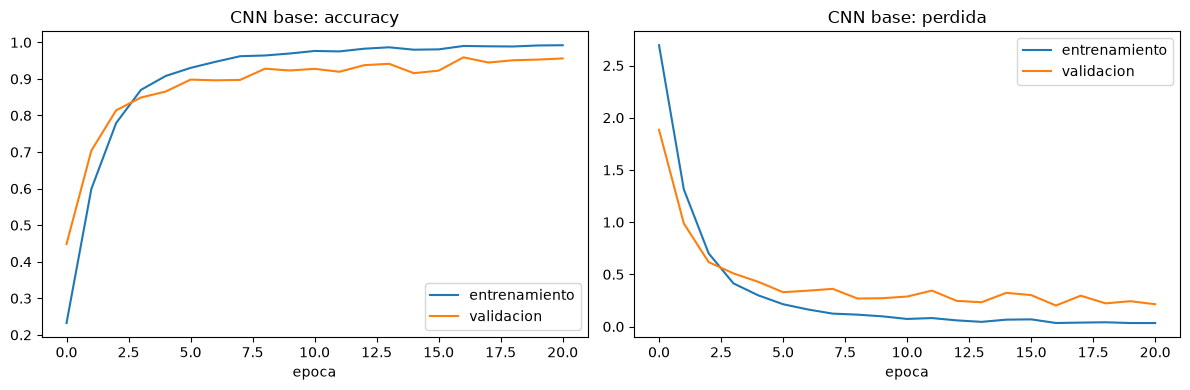

  mejor epoca            : 17
  accuracy entrenamiento : 0.9901
  accuracy validacion    : 0.9590
  brecha                 : 0.0311


In [7]:
graficar_curvas(hist_base, "CNN base")
brecha(hist_base)

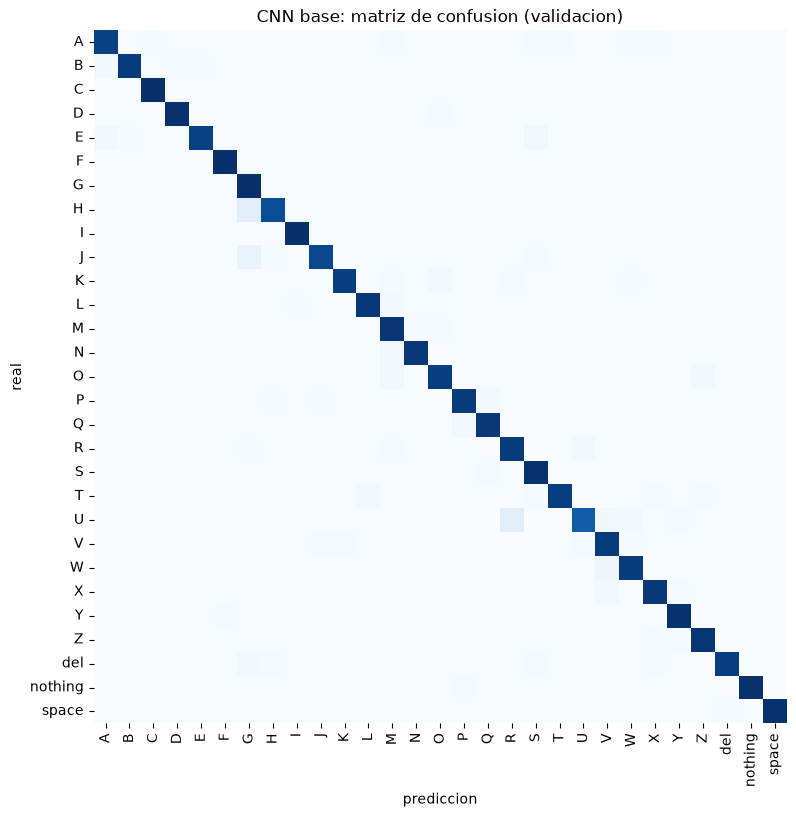

Confusiones mas frecuentes:
  H       predicha como G       : 10
  U       predicha como R       : 10
  J       predicha como G       : 6
  W       predicha como V       : 4
  E       predicha como S       : 3
  N       predicha como M       : 3
  O       predicha como M       : 3
  Q       predicha como P       : 3
  U       predicha como V       : 3
  B       predicha como A       : 2


In [8]:
graficar_matriz(res_base, "CNN base")
print("Confusiones mas frecuentes:")
peores_confusiones(res_base)

### **Discusion de la CNN base**

Antes de entrar a los resultados, cabe mencionar que la metrica seleccionada para evaluar fue
accuracy, tal como se justifico en los documentos anteriores. La razon es que la naturaleza del
problema no favorece el enfocarnos en evaluar falsos positivos o falsos negativos, ya que no
hay una clase cuyo error cueste mas que el de las demas, sino que interesa el desempeño general
del modelo, en donde todas las letras importan por igual.

Dicho esto, al comparar el accuracy sobre el conjunto de entrenamiento contra el de validacion
se observa que ambas curvas se mantienen bastante cercanas en el grafico: no llegan a solaparse
del todo, pero si conservan la misma forma. En la mejor epoca el accuracy en entrenamiento fue
de 0.9901 y el de validacion de 0.9590, de tal forma que la brecha entre ambos es de apenas
0.0311. Considero que esto es una buena señal, ya que se puede decir que la red no quedo
sobreajustada, dado que el desempeño no se vio afectado de forma importante al pasar del
conjunto con el que aprendio al conjunto que nunca habia visto. Por ejemplo, si hubieramos
observado un rendimiento muy alto en entrenamiento y una caida fuerte al llegar a validacion,
ahi si estariamos hablando de un modelo sobreajustado.

Asimismo, al analizar la perdida a lo largo de las epocas se destaca algo bastante interesante.
La perdida de entrenamiento baja de forma sostenida hasta quedar practicamente en cero, cerca de
0.03, mientras que la de validacion deja de bajar alrededor de la sexta epoca y de ahi en
adelante se queda oscilando entre 0.20 y 0.36 sin una tendencia clara. Sin embargo, el accuracy
de validacion si sigue mejorando durante ese mismo tramo, hasta alcanzar su mejor punto en la
epoca 17. Es decir, la red va acertando mas casos aunque su nivel de error deje de mejorar, lo
que sugiere que se esta volviendo mas confiada en sus aciertos pero tambien en algunas de sus
equivocaciones. Cabe mencionar que esa distancia entre una perdida de entrenamiento de 0.03 y
una de validacion de 0.20 es coherente con la brecha de accuracy que ya se menciono, y confirma
que existe un sobreajuste leve, aunque no lo suficientemente grande como para comprometer el
resultado.

El EarlyStopping cumplio su funcion en este escenario: al no encontrar mejoras durante cuatro
epocas seguidas despues de la 17, corto el entrenamiento en la epoca 21 y restauro los pesos del
mejor punto. Bajo esta idea, el tope de 30 epocas que se habia fijado nunca llego a agotarse, de
forma que el presupuesto resulto adecuado y no fue necesario ampliarlo.

Finalmente, al analizar la matriz de confusion se identifica que la mayoria de las veces todas
las letras quedan clasificadas correctamente, incluyendo las clases de accion como nothing,
space y del. Las confusiones mas frecuentes son en su mayoria las esperadas: la H se predice
como G en diez ocasiones y la U como R tambien en diez, que son justamente pares que se
diferencian por detalles muy finos, ya sea por cuantos dedos se extienden hacia el mismo lado o
por si los dedos van juntos o cruzados. Despues aparece la J predicha como G en seis ocasiones,
que resulta menos evidente a simple vista, y la W como V en cuatro. En todos los casos la
cantidad de errores es bastante baja frente al total evaluado.

## **Variante 2: CNN regularizada**

Mismo esqueleto convolucional que la anterior. Lo unico que cambia es la incorporacion de
normalizacion por lotes y dropout.

In [9]:
regularizada = construir_regularizada()
regularizada.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

hist_reg, t_reg = m.entrenar(regularizada, datos, batch_size=64)
res_reg = m.evaluar(regularizada, datos)
reg_reg = m.registrar("cnn_regularizada", regularizada, res_reg, t_reg,
                      historial=hist_reg, batch_size=64,
                      notas="mismos 3 bloques 32/64/64 + BatchNorm y dropout, densa 128, Adam lr=0.001")

Epoch 1/30
191/191 - 27s - 140ms/step - accuracy: 0.0432 - loss: 3.3707 - val_accuracy: 0.0345 - val_loss: 3.6610
Epoch 2/30
191/191 - 23s - 121ms/step - accuracy: 0.0516 - loss: 3.2876 - val_accuracy: 0.0345 - val_loss: 4.1238
Epoch 3/30
191/191 - 25s - 130ms/step - accuracy: 0.0524 - loss: 3.2655 - val_accuracy: 0.0628 - val_loss: 3.3528
Epoch 4/30
191/191 - 21s - 108ms/step - accuracy: 0.0594 - loss: 3.2239 - val_accuracy: 0.1073 - val_loss: 3.0649
Epoch 5/30
191/191 - 22s - 113ms/step - accuracy: 0.0603 - loss: 3.1552 - val_accuracy: 0.1142 - val_loss: 2.9870
Epoch 6/30
191/191 - 22s - 117ms/step - accuracy: 0.0665 - loss: 3.1177 - val_accuracy: 0.1008 - val_loss: 2.9414
Epoch 7/30
191/191 - 22s - 117ms/step - accuracy: 0.0790 - loss: 3.0720 - val_accuracy: 0.1464 - val_loss: 2.8086
Epoch 8/30
191/191 - 22s - 115ms/step - accuracy: 0.0819 - loss: 3.0395 - val_accuracy: 0.1805 - val_loss: 2.6970
Epoch 9/30
191/191 - 22s - 117ms/step - accuracy: 0.0881 - loss: 3.0066 - val_accuracy: 

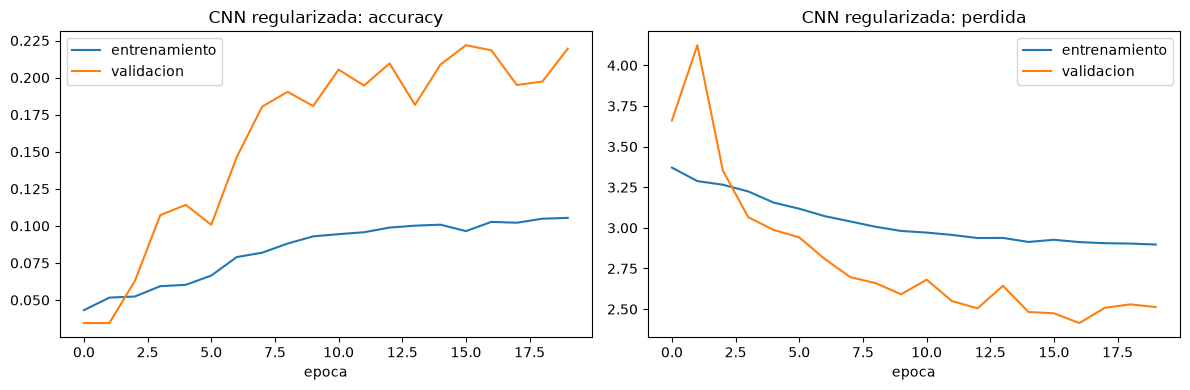

  mejor epoca            : 16
  accuracy entrenamiento : 0.0965
  accuracy validacion    : 0.2218
  brecha                 : -0.1254


In [10]:
graficar_curvas(hist_reg, "CNN regularizada")
brecha(hist_reg)

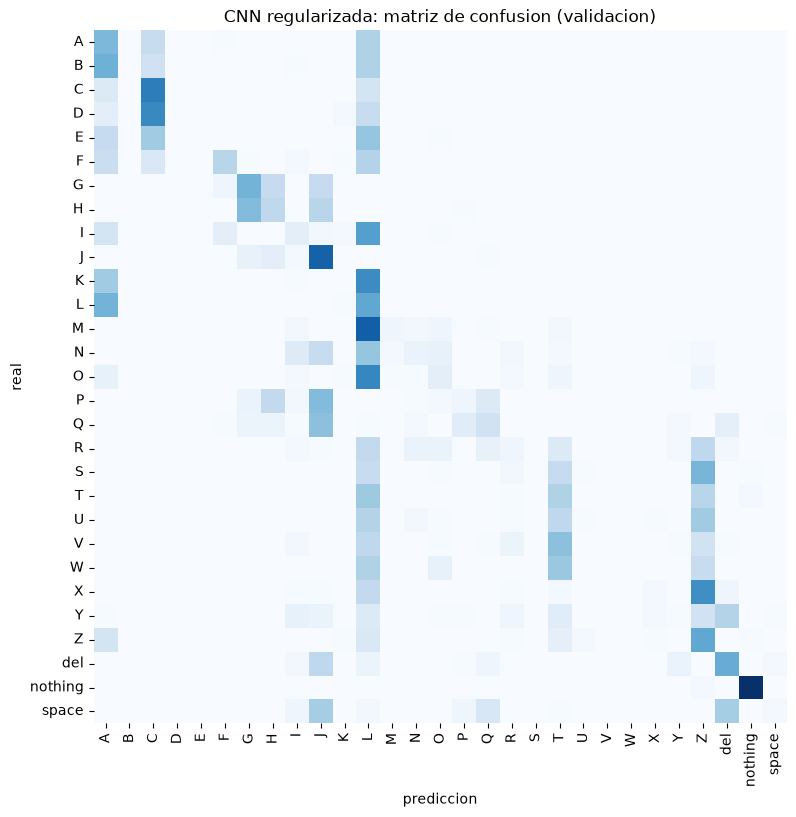

Confusiones mas frecuentes:
  M       predicha como L       : 72
  O       predicha como L       : 59
  D       predicha como C       : 58
  K       predicha como L       : 57
  X       predicha como Z       : 56
  I       predicha como L       : 50
  B       predicha como A       : 43
  L       predicha como A       : 42
  S       predicha como Z       : 41
  H       predicha como G       : 39


In [11]:
graficar_matriz(res_reg, "CNN regularizada")
print("Confusiones mas frecuentes:")
peores_confusiones(res_reg)

### **Discusion de la CNN regularizada**

La idea detras de esta segunda variante era probar una red regularizada por medio de batch
normalization, que lo que hace es mantener los valores dentro de la red de forma escalada para
que ninguno se vaya muy elevado, y a la vez utilizar dropout, que apaga algunas neuronas con
cierta probabilidad para poder evitar el sobreajuste.

No obstante, esto termino siendo contraproducente. Al analizar los graficos de accuracy y de
perdida se observa un rendimiento totalmente distinto al de la base: el accuracy en
entrenamiento fue de 0.0965 mientras que el de validacion fue de 0.2218, un comportamiento
bastante peculiar, sobre todo porque esperariamos que en entrenamiento se tenga un mejor
rendimiento que en validacion.

Cabe mencionar que ese cruce tiene una explicacion concreta y no es un error de medicion.
Durante el entrenamiento la metrica se calcula con el dropout activo, es decir con una parte de
las neuronas apagadas y usando las estadisticas del propio lote en el batch normalization,
mientras que en validacion la red se evalua en modo inferencia, con todas las neuronas
encendidas y con las estadisticas acumuladas. Es por esto que en redes fuertemente
regularizadas el accuracy de entrenamiento tiende a salir sistematicamente por debajo del de
validacion, de tal forma que no debe leerse como que el modelo rinde mejor sobre datos que
nunca vio.

Dicho esto, aun tomando unicamente el accuracy de validacion, ese 0.2218 representa una
diferencia de mas de 0.7 al contrastarlo contra la CNN base. Es por esto que se puede decir que
el modelo, en vez de sufrir sobreajuste, ahora quedo infraajustado: no aprendio ni memorizo,
pero tampoco logro generalizar lo que vio durante el entrenamiento, que de por si fue bastante
bajo, probablemente como consecuencia de las probabilidades de dropout seleccionadas.

Asimismo, al analizar la perdida se ve que con cada epoca si se logro ir reduciendo el error,
no obstante la cantidad de letras correctamente identificadas sigue siendo demasiado baja. Para
poder dimensionarlo, con 29 clases un clasificador que decidiera al azar acertaria alrededor
del 3.45% de las veces, de forma que la red si aprendio algo, ya que 0.2218 es cerca de 6.4
veces mejor que el azar; no obstante, acertar poco mas de 2 de cada 10 letras sigue siendo
inaceptable para un producto que busca traducir seña por seña en tiempo real, y por lo tanto no
es un modelo que se utilizaria realmente en produccion.

Esto se ve reforzado al analizar la matriz de confusion. En la CNN base se lograba visualizar
una diagonal casi perfecta en el centro, que se miraba bastante oscura a lo largo de toda esa
area; sin embargo, en esta matriz los cuadrados y la intensidad del azul varian
considerablemente. Lo peculiar es que la L, por ejemplo, se confunde con un monton de letras,
y de hecho las dos confusiones mas frecuentes fueron que la M se predijo como L 72 veces y que
la O se predijo como L 59 veces.

## **Comparacion entre las variantes convolucionales**

Solo sobre validacion. La comparacion contra la red simple y el Random Forest se hace al
final del laboratorio, en un notebook aparte.

In [12]:
tabla = pd.DataFrame([
    {"modelo": r["nombre"],
     "accuracy_val": round(r["accuracy"], 4),
     "epocas": r["epocas_corridas"],
     "tiempo_seg": r["tiempo_entrenamiento_seg"],
     "notas": r["notas"]}
    for r in (reg_base, reg_reg)
]).sort_values("accuracy_val", ascending=False)

tabla

,modelo,accuracy_val,epocas,tiempo_seg,notas
0,cnn_base,0.9590,21,428.1,"3 bloques conv 32/64/64, densa 128, sin regula..."
1,cnn_regularizada,0.2218,20,451.7,mismos 3 bloques 32/64/64 + BatchNorm y dropou...


### **Discusion de la comparacion**

Al contrastar las dos variantes convolucionales sobre validacion, la diferencia es contundente:
la CNN base alcanzo un accuracy de 0.9590 mientras que la regularizada se quedo en 0.2218, es
decir una brecha de 0.7372 entre ambas. Cabe mencionar que, dado que las dos redes comparten
exactamente el mismo esqueleto convolucional, los mismos tres bloques de 32, 64 y 64 filtros,
la misma capa densa de 128 y el mismo optimizador con el mismo learning rate y el mismo batch
size, esa diferencia no se puede atribuir a capacidad ni a presupuesto de entrenamiento, sino
unicamente a la incorporacion de batch normalization y dropout.

Bajo esta idea, considero que lo que ocurrio es que la regularizacion estaba atacando un
problema que en realidad no existia. La CNN base cerro con una brecha de apenas 0.0311 entre
entrenamiento y validacion, o sea que mostro a lo sumo un sobreajuste leve, y es por esto que al
agregarle dropout de 0.25 despues de cada pooling y de 0.5 antes de la salida lo unico que se
logro fue impedir que la red aprendiera; en vez de corregir un sobreajuste que apenas estaba
presente, terminamos empujando al modelo hacia el infraajuste.

En cuanto al costo, cabe mencionar que las dos variantes resultaron practicamente equivalentes:
la base corrio 21 epocas en 428.1 segundos y la regularizada 20 epocas en 451.7 segundos, es
decir apenas un 5.5% mas de tiempo. Dicho esto, el tiempo no es el criterio que las separa, ya
que el calculo adicional que introduce el batch normalization queda compensado por haber
entrenado una epoca menos. Lo que decide la comparacion es el accuracy, y ahi la distancia no
admite discusion.

Es por esto que la variante que se selecciona para la comparacion final contra la red neuronal
simple y el Random Forest es la CNN base.

## **Variante 3: barrido de la intensidad de regularizacion**

Las dos variantes anteriores muestran que el problema de la CNN regularizada no fue usar
regularizacion, sino la intensidad con la que se aplico. Es por esto que la tercera variante
mantiene exactamente la misma arquitectura regularizada y unicamente baja las probabilidades de
dropout, de 0.25 a 0.1 despues de cada pooling y de 0.5 a 0.2 antes de la salida. Todo lo demas
se mantiene igual: mismos filtros, misma densa, mismo optimizador, mismo learning rate y mismo
batch size.

In [13]:
suave = construir_regularizada(dropout_conv=0.1, dropout_densa=0.2)
suave.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

hist_suave, t_suave = m.entrenar(suave, datos, batch_size=64)
res_suave = m.evaluar(suave, datos)
reg_suave = m.registrar("cnn_regularizada_suave", suave, res_suave, t_suave,
                        historial=hist_suave, batch_size=64,
                        notas="misma arquitectura regularizada con dropout 0.1 y 0.2, Adam lr=0.001")

Epoch 1/30
191/191 - 24s - 126ms/step - accuracy: 0.0936 - loss: 3.1733 - val_accuracy: 0.0345 - val_loss: 4.7715
Epoch 2/30
191/191 - 21s - 112ms/step - accuracy: 0.1932 - loss: 2.6094 - val_accuracy: 0.0364 - val_loss: 6.0169
Epoch 3/30
191/191 - 22s - 113ms/step - accuracy: 0.2765 - loss: 2.2178 - val_accuracy: 0.1153 - val_loss: 4.0002
Epoch 4/30
191/191 - 20s - 105ms/step - accuracy: 0.3365 - loss: 1.9912 - val_accuracy: 0.3770 - val_loss: 1.9447
Epoch 5/30
191/191 - 21s - 112ms/step - accuracy: 0.3842 - loss: 1.8306 - val_accuracy: 0.3605 - val_loss: 2.1145
Epoch 6/30
191/191 - 22s - 115ms/step - accuracy: 0.4057 - loss: 1.7403 - val_accuracy: 0.3372 - val_loss: 2.9550
Epoch 7/30
191/191 - 20s - 107ms/step - accuracy: 0.4241 - loss: 1.6746 - val_accuracy: 0.4391 - val_loss: 1.9626
Epoch 8/30
191/191 - 20s - 102ms/step - accuracy: 0.4435 - loss: 1.6321 - val_accuracy: 0.4877 - val_loss: 1.6147
Epoch 9/30
191/191 - 20s - 105ms/step - accuracy: 0.4577 - loss: 1.5651 - val_accuracy: 

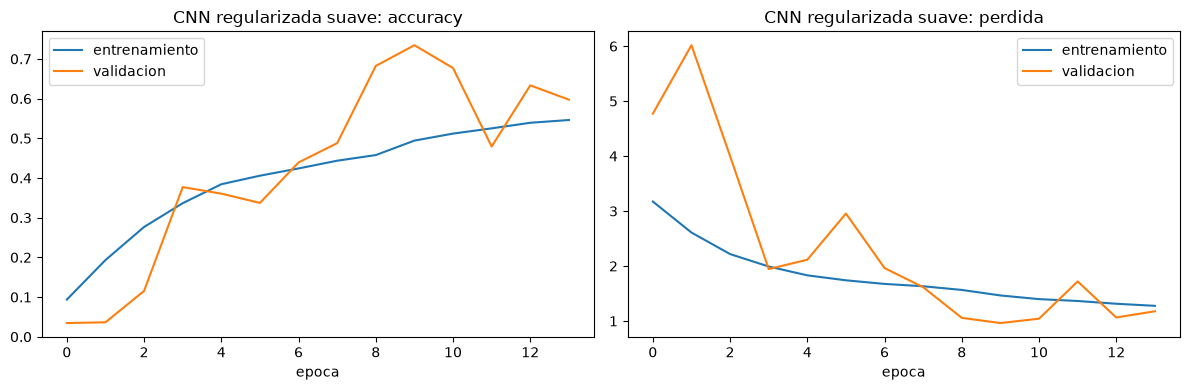

  mejor epoca            : 10
  accuracy entrenamiento : 0.4942
  accuracy validacion    : 0.7345
  brecha                 : -0.2403


In [14]:
graficar_curvas(hist_suave, "CNN regularizada suave")
brecha(hist_suave)

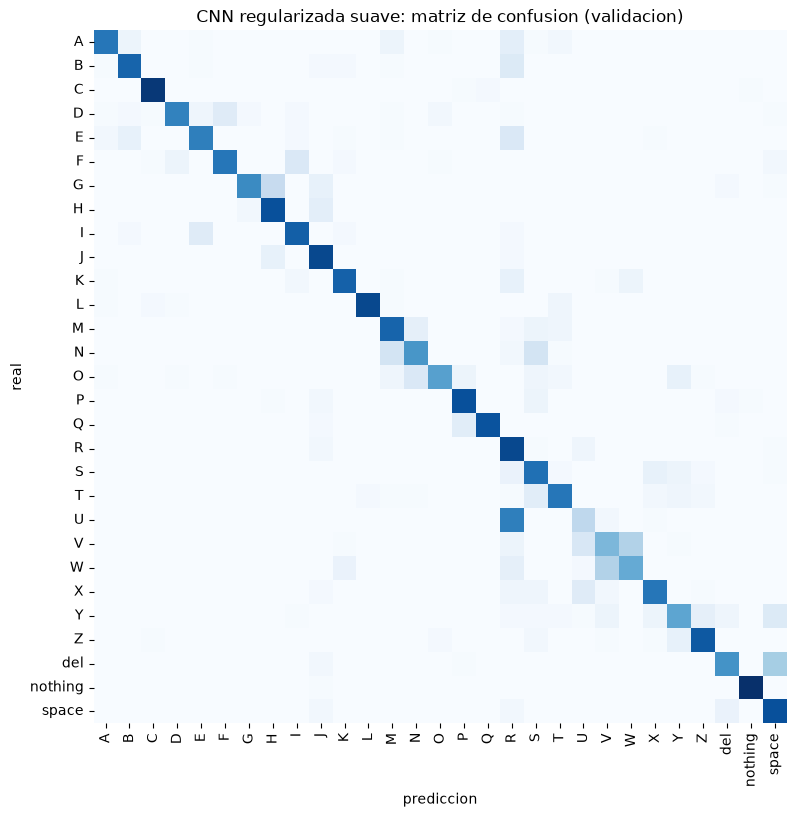

Confusiones mas frecuentes:
  U       predicha como R       : 62
  del     predicha como space   : 31
  V       predicha como W       : 28
  W       predicha como V       : 28
  G       predicha como H       : 22
  N       predicha como M       : 16
  N       predicha como S       : 16
  V       predicha como U       : 14
  E       predicha como R       : 13
  F       predicha como I       : 13


In [15]:
graficar_matriz(res_suave, "CNN regularizada suave")
print("Confusiones mas frecuentes:")
peores_confusiones(res_suave)

### **Discusion de la variante 3**

En este tercer modelo se tomo la decision de seguir trabajando con regularizacion, pero bajando
su intensidad, especificamente bajando la probabilidad de dropout para poder limitar la
cantidad de neuronas que se apagan y de esta forma tratar de mitigar el comportamiento de
infraajuste que mostro la variante anterior.

Al analizar el accuracy vuelve a presentarse el mismo fenomeno que ya se explico, y es que como
al momento de validar se deja de apagar neuronas, el accuracy de entrenamiento queda medido en
desventaja frente al de validacion. En este caso el entrenamiento llego a 0.4942 mientras que
validacion llego a 0.7345, de tal forma que la brecha de 0.2403 vuelve a salir invertida
respecto a lo que uno esperaria, que es que el mejor rendimiento se de en entrenamiento y que
despues baje al pasar a validacion y a prueba.

Asimismo, al analizar el comportamiento de la perdida conforme avanzan las epocas se ve que en
entrenamiento baja de forma constante, mientras que en validacion baja con mayor intensidad.
Solamente al llegar a las ultimas epocas, alrededor de la decima y la doceava, se deja de
visualizar ese decremento, e incluso llega a formarse un pico en donde el error sube, para
luego volver a bajar en la doceava epoca.

Dicho esto, al analizar la matriz de confusion se observa una mejora considerable frente a lo
que presento el segundo modelo, ya que en esta si se logra ver claramente la diagonal. No
obstante, hay mas cuadros dispersos a lo largo de la matriz, lo que quiere decir que siguen
habiendo bastantes confusiones en comparacion al primer modelo, en donde la diagonal se veia
casi perfecta en cuanto a intensidad.

Cabe mencionar que la frecuencia de los errores tambien sigue siendo bastante elevada en
contraste con el primer modelo. Por ejemplo, en la CNN base la confusion mas alta era de
solamente nueve ocasiones, entre la W y la V, que son letras bastante similares entre si,
mientras que en esta variante la U se predijo como R en 62 ocasiones.

## **Tabla final de las variantes convolucionales**

In [16]:
tabla_final = pd.DataFrame([
    {"modelo": r["nombre"],
     "accuracy_val": round(r["accuracy"], 4),
     "epocas": r["epocas_corridas"],
     "tiempo_seg": r["tiempo_entrenamiento_seg"],
     "notas": r["notas"]}
    for r in (reg_base, reg_reg, reg_suave)
]).sort_values("accuracy_val", ascending=False)

tabla_final

,modelo,accuracy_val,epocas,tiempo_seg,notas
0,cnn_base,0.9590,21,428.1,"3 bloques conv 32/64/64, densa 128, sin regula..."
2,cnn_regularizada_suave,0.7345,14,304.0,misma arquitectura regularizada con dropout 0....
1,cnn_regularizada,0.2218,20,451.7,mismos 3 bloques 32/64/64 + BatchNorm y dropou...


### **Discusion final y seleccion**

Al juntar las tres variantes convolucionales en una sola tabla el orden queda claro: la CNN base
alcanzo 0.9590 de accuracy en validacion, la regularizada suave 0.7345 y la regularizada
agresiva 0.2218. Cabe mencionar que las tres comparten exactamente el mismo esqueleto
convolucional, el mismo optimizador, el mismo learning rate y el mismo batch size, de tal forma
que la unica variable que cambio a lo largo del experimento fue la regularizacion y su
intensidad, y por lo tanto todo el efecto observado se le puede atribuir a ella.

Bajo esta idea, el barrido de la tercera variante confirma la lectura que se hizo de la segunda.
Al bajar el dropout de 0.25 y 0.5 a 0.1 y 0.2, el accuracy en validacion paso de 0.2218 a
0.7345, es decir que se recuperaron mas de 0.51 puntos unicamente moderando cuantas neuronas se
apagan. Es por esto que se puede afirmar que el problema nunca fue regularizar, sino la
intensidad con la que se hizo, ya que con probabilidades tan altas la red simplemente no
alcanzaba a aprender.

No obstante, ni siquiera la version moderada logra acercarse a la base, que sigue estando 0.2245
por encima. Considero que la explicacion es que la regularizacion estaba corrigiendo un problema
que apenas existia: la CNN base cerro con una brecha de solo 0.0311 entre entrenamiento y
validacion, y bajo ese escenario cualquier cantidad de dropout le resta capacidad de aprendizaje
sin darle demasiado a cambio.

En cuanto al costo, los tiempos no ordenan a los modelos de la misma manera que el accuracy. La
base corrio 21 epocas en 428.1 segundos, la regularizada agresiva 20 epocas en 451.7 segundos y
la suave 14 epocas en 304.0 segundos. Es decir que la variante suave fue la mas barata de las
tres, pero unicamente porque el EarlyStopping la corto antes al dejar de mejorar, no porque sea
mas eficiente por diseño. Dicho esto, entrenar mas rapido no compensa quedarse 0.2245 por debajo
en accuracy.

Finalmente, vale la pena mirar no solo cuanto error comete cada modelo sino de que tipo es. En
la CNN base los errores mas frecuentes son la H predicha como G y la U predicha como R, ambas
en diez ocasiones, o sea que sus equivocaciones se concentran en pares de letras que
efectivamente son parecidas entre si y que uno esperaria que costaran. En cambio, en las
variantes regularizadas los errores son masivos y mucho menos interpretables, como la M predicha
como L en 72 ocasiones en la version agresiva, o la U predicha como R en 62 ocasiones en la
moderada.

Es por esto que el modelo que se selecciona para la comparacion final contra la red neuronal
simple y el Random Forest es la CNN base.